# Neural Network vs. Random Forest

Notebook ini bertujuan untuk membandingkan performa dua model machine learning, yaitu **Neural Network (MLP)** dan **Random Forest**, pada dataset *Online Shoppers Intention*.

### 1. Import Library

Langkah pertama adalah mengimpor semua library yang dibutuhkan.

In [ ]:
# Menginstall semua library yang dibutuhkan jika belum ada
%pip install pandas numpy seaborn matplotlib scikit-learn imbalanced-learn jinja2 --quiet

In [1]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# Mengatur agar output tidak terpotong
pd.set_option('display.max_columns', None)

print(f"✓ Scikit-learn version: {sklearn.__version__}")
print("✓ All libraries imported successfully!")

✓ Scikit-learn version: 1.8.0
✓ All libraries imported successfully!


### 2. Load & Preprocessing Data

- Dataset: `online_shoppers_intention.csv`
- Target: `Revenue`
- Preprocessing: One-Hot Encoding untuk fitur kategorikal.

In [2]:
# Load dataset
df = pd.read_csv('online_shoppers_intention.csv')

display(df.head())

# Pisahkan fitur (X) dan target (y)
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Identifikasi fitur kategorikal dan numerik
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# One-Hot Encoding untuk fitur kategorikal
# handle_unknown='ignore' untuk mengatasi nilai yang mungkin ada di test set tapi tidak di train set
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = pd.DataFrame(encoder.fit_transform(X[categorical_features]))
X_encoded.columns = encoder.get_feature_names_out(categorical_features)

# Gabungkan kembali fitur numerik dan yang sudah di-encode
X = X.drop(categorical_features, axis=1)
X = pd.concat([X, X_encoded], axis=1)

print("\nDimensi data setelah preprocessing:", X.shape)
print("Data setelah One-Hot Encoding (sebelum scaling):")
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Dimensi data setelah preprocessing: (12330, 29)
Data setelah One-Hot Encoding (sebelum scaling):


/var/folders/lk/wc9vhhns1fn7k7j4sx2dl0t00000gn/T/ipykernel_53062/2542351919.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'bool']).columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_False,Weekend_True
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,3,2,2,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,3,3,1,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


### 3. Split Data (Train-Test)

- Pembagian data: 80% training, 20% testing.
- `stratify=y`: Memastikan proporsi kelas pada data training dan testing sama dengan proporsi pada data asli. Penting untuk data yang tidak seimbang.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Distribusi kelas pada y_train:\n", y_train.value_counts(normalize=True))
print("\nDistribusi kelas pada y_test:\n", y_test.value_counts(normalize=True))

Distribusi kelas pada y_train:
 Revenue
False    0.845296
True     0.154704
Name: proportion, dtype: float64

Distribusi kelas pada y_test:
 Revenue
False    0.845093
True     0.154907
Name: proportion, dtype: float64


### 4. Penanganan Data Imbalance (SMOTE)

- **SMOTE (Synthetic Minority Over-sampling Technique):** Digunakan untuk mengatasi ketidakseimbangan kelas.
- SMOTE diterapkan pada data training untuk mencegah *data leakage* (informasi dari data testing bocor ke proses training).

In [4]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribusi kelas setelah SMOTE:\n", y_train_res.value_counts(normalize=True))

Distribusi kelas setelah SMOTE:
 Revenue
False    0.5
True     0.5
Name: proportion, dtype: float64


### 5. Scaling Data (StandardScaler)

- **StandardScaler:** Mengubah skala fitur sehingga memiliki rata-rata 0 dan standar deviasi 1.
- **Penting:** Scaling hanya diperlukan untuk model Neural Network.
- Scaler di-`fit` hanya pada data training (`X_train_res`) dan kemudian digunakan untuk mentransformasi `X_train_res` dan `X_test`.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

### 6. Model 1: Neural Network (MLP)

- **Arsitektur:**
    - Input Layer
    - Dense(128, ReLU) + Dropout(0.5)
    - Dense(64, ReLU) + Dropout(0.3)
    - Output Layer: Dense(1, Sigmoid) untuk klasifikasi biner.
- **Kompilasi:**
    - `optimizer='adam'`
    - `loss='binary_crossentropy'`
    - `metrics=['accuracy']`
- **EarlyStopping:** Menghentikan training jika tidak ada peningkatan pada `val_loss` setelah 5 epoch (`patience=5`) untuk mencegah overfitting.

In [6]:
# Mendefinisikan model
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    alpha=0.0001,
    learning_rate_init=0.001,
    random_state=42,
    verbose=True
)

# --- Training ---
start_time_nn_train = time.time()
mlp_model.fit(X_train_scaled, y_train_res)
end_time_nn_train = time.time()
runtime_nn_train = end_time_nn_train - start_time_nn_train

# --- Prediksi ---
start_time_nn_pred = time.time()
y_pred_nn = mlp_model.predict(X_test_scaled)
end_time_nn_pred = time.time()
runtime_nn_pred = end_time_nn_pred - start_time_nn_pred

# --- Evaluasi ---
accuracy_nn = accuracy_score(y_test, y_pred_nn)

print(f"\nNeural Network Training Time: {runtime_nn_train:.4f} seconds")
print(f"Neural Network Prediction Time: {runtime_nn_pred:.4f} seconds")
print(f"Neural Network Accuracy: {accuracy_nn:.4f}")

Iteration 1, loss = 0.46426914
Validation score: 0.845923
Iteration 2, loss = 0.32503463
Validation score: 0.869904
Iteration 3, loss = 0.28474205
Validation score: 0.888489
Iteration 4, loss = 0.25690139
Validation score: 0.892086
Iteration 5, loss = 0.23788766
Validation score: 0.895084
Iteration 6, loss = 0.21927861
Validation score: 0.893285
Iteration 7, loss = 0.20515944
Validation score: 0.895683
Iteration 8, loss = 0.20930671
Validation score: 0.899281
Iteration 9, loss = 0.19745940
Validation score: 0.901679
Iteration 10, loss = 0.17702775
Validation score: 0.904676
Iteration 11, loss = 0.17633680
Validation score: 0.904077
Iteration 12, loss = 0.17194058
Validation score: 0.913669
Iteration 13, loss = 0.16390983
Validation score: 0.908273
Iteration 14, loss = 0.15434983
Validation score: 0.914269
Iteration 15, loss = 0.15456553
Validation score: 0.904676
Iteration 16, loss = 0.15045095
Validation score: 0.918465
Iteration 17, loss = 0.13874756
Validation score: 0.916067
Iterat

### 7. Model 2: Random Forest

- **Parameter:**
    - `n_estimators=300`: Jumlah pohon dalam forest.
    - `max_depth=15`: Kedalaman maksimum setiap pohon.
    - `random_state=42`: Untuk reproduktifitas hasil.
- **Data:** Menggunakan data yang sudah di-SMOTE tetapi **tidak di-scaling** (`X_train_res`, `y_train_res`). Random Forest tidak sensitif terhadap skala fitur.

In [7]:
# Mendefinisikan model
rf_model = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1, verbose=1)

# --- Training ---
start_time_rf_train = time.time()
rf_model.fit(X_train_res, y_train_res)
end_time_rf_train = time.time()
runtime_rf_train = end_time_rf_train - start_time_rf_train

# --- Prediksi ---
start_time_rf_pred = time.time()
y_pred_rf = rf_model.predict(X_test)
end_time_rf_pred = time.time()
runtime_rf_pred = end_time_rf_pred - start_time_rf_pred

# --- Evaluasi ---
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nRandom Forest Training Time: {runtime_rf_train:.4f} seconds")
print(f"Random Forest Prediction Time: {runtime_rf_pred:.4f} seconds")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.5s



Random Forest Training Time: 0.8259 seconds
Random Forest Prediction Time: 0.0369 seconds
Random Forest Accuracy: 0.8970


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    0.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.0s finished


### 8. Perbandingan Hasil

Menampilkan hasil perbandingan kedua model dalam format tabel yang rapi.

In [8]:
# Membuat DataFrame untuk perbandingan
results = {
    'Model': ['Neural Network (MLP)', 'Random Forest'],
    'Accuracy': [accuracy_nn, accuracy_rf],
    'Runtime Training (s)': [runtime_nn_train, runtime_rf_train],
    'Runtime Prediction (s)': [runtime_nn_pred, runtime_rf_pred]
}

comparison_df = pd.DataFrame(results)

# Menampilkan tabel perbandingan
comparison_df.set_index('Model', inplace=True)
comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Runtime Training (s)': '{:.4f}',
    'Runtime Prediction (s)': '{:.4f}'
})

,Accuracy,Runtime Training (s),Runtime Prediction (s)
Model,,,
Neural Network (MLP),0.8658,2.3572,0.0025
Random Forest,0.8970,0.8259,0.0369


### 8. Confusion Matrix Visualization

Visualisasi confusion matrix untuk kedua model secara berdampingan.

**Interpretasi Confusion Matrix:**
- **True Negative (TN):** Model benar memprediksi "Tidak Beli"
- **True Positive (TP):** Model benar memprediksi "Beli"
- **False Positive (FP):** Model salah memprediksi "Beli" (seharusnya "Tidak Beli")
- **False Negative (FN):** Model salah memprediksi "Tidak Beli" (seharusnya "Beli")

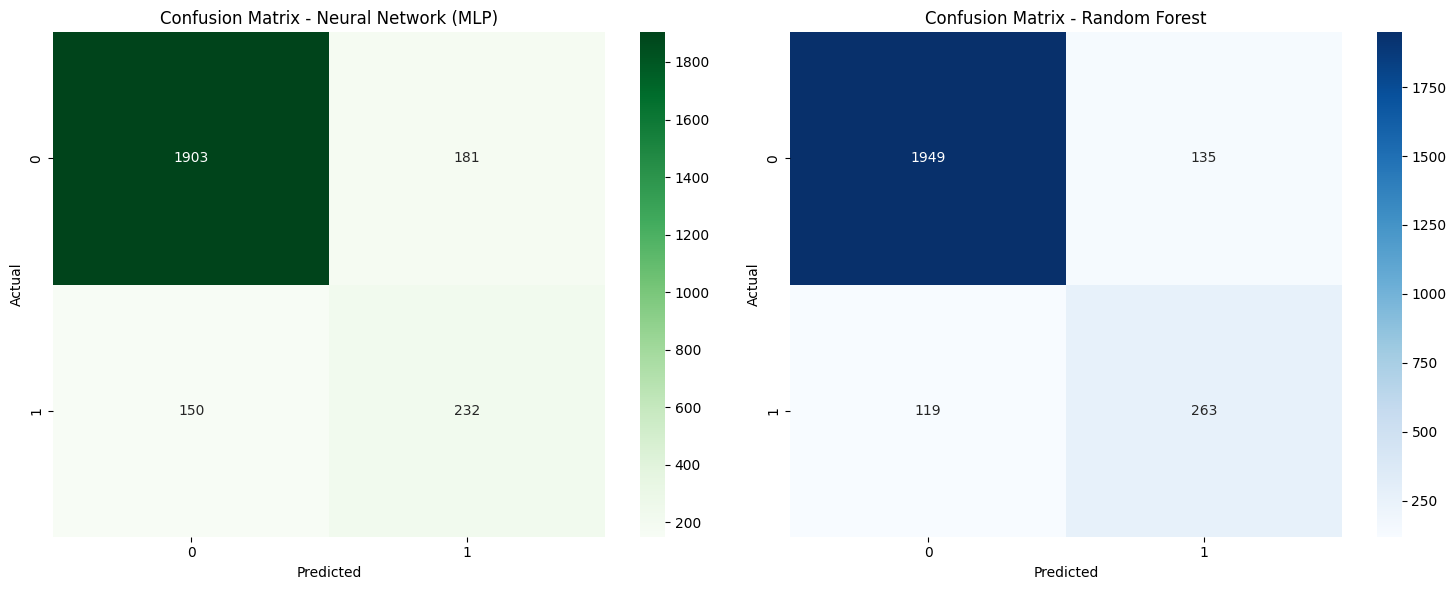

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Membuat confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix Neural Network
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Confusion Matrix - Neural Network (MLP)')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Confusion Matrix Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix - Random Forest')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 9. Classification Report & Feature Importance

Analisis detail performa model dan fitur yang paling berpengaruh

In [12]:
# ==================================================
# 9. CLASSIFICATION REPORT - KEDUA MODEL
# ==================================================
from sklearn.metrics import classification_report

print("\n" + "="*70)
print("CLASSIFICATION REPORT - NEURAL NETWORK (MLP)")
print("="*70)
print(classification_report(y_test, y_pred_nn, 
                          target_names=['Tidak Beli (0)', 'Beli (1)'],
                          digits=4))

print("\n" + "="*70)
print("CLASSIFICATION REPORT - RANDOM FOREST")
print("="*70)
print(classification_report(y_test, y_pred_rf,
                          target_names=['Tidak Beli (0)', 'Beli (1)'],
                          digits=4))


CLASSIFICATION REPORT - NEURAL NETWORK (MLP)
                precision    recall  f1-score   support

Tidak Beli (0)     0.9269    0.9131    0.9200      2084
      Beli (1)     0.5617    0.6073    0.5836       382

      accuracy                         0.8658      2466
     macro avg     0.7443    0.7602    0.7518      2466
  weighted avg     0.8704    0.8658    0.8679      2466


CLASSIFICATION REPORT - RANDOM FOREST
                precision    recall  f1-score   support

Tidak Beli (0)     0.9425    0.9352    0.9388      2084
      Beli (1)     0.6608    0.6885    0.6744       382

      accuracy                         0.8970      2466
     macro avg     0.8016    0.8119    0.8066      2466
  weighted avg     0.8988    0.8970    0.8979      2466



### 10. Feature Importance Analysis

Analisis 10 fitur yang paling mempengaruhi prediksi model Random Forest

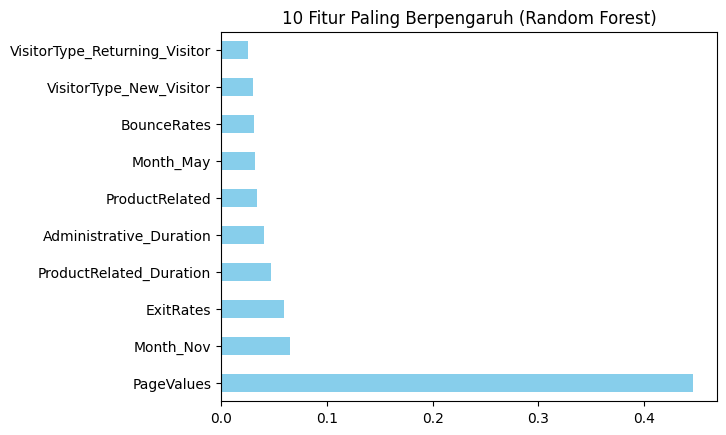

In [11]:
# Ambil 10 fitur teratas
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('10 Fitur Paling Berpengaruh (Random Forest)')
plt.show()

### 11. Analisis Detail Confusion Matrix

Penjelasan detail hasil confusion matrix untuk kedua model

In [18]:
# ==================================================
# 11. ANALISIS DETAIL CONFUSION MATRIX
# ==================================================

print("="*80)
print("ANALISIS DETAIL CONFUSION MATRIX")
print("="*80)

# Confusion matrix sudah dihitung di cell sebelumnya
# cm_nn = confusion matrix untuk Neural Network (MLP)
# cm_rf = confusion matrix untuk Random Forest

# ========== NEURAL NETWORK (MLP) ==========
print("\n" + "="*80)
print("MODEL 1: NEURAL NETWORK (MLP)")
print("="*80)

tn_nn, fp_nn, fn_nn, tp_nn = cm_nn.ravel()

print(f"\nConfusion Matrix Array:")
print(f"[[ {tn_nn:5d}   {fp_nn:5d} ]")
print(f" [ {fn_nn:5d}   {tp_nn:5d} ]]")

print(f"\n► TRUE NEGATIVE (TN)  = {tn_nn}")
print(f"  Makna: Model BENAR memprediski 'Tidak Beli' (Label 0)")
print(f"  → {tn_nn} pelanggan yang sebenarnya tidak membeli, diprediksi dengan benar")

print(f"\n► FALSE POSITIVE (FP) = {fp_nn}")
print(f"  Makna: Model SALAH memprediski 'Beli' (seharusnya 'Tidak Beli')")
print(f"  → {fp_nn} pelanggan yang tidak membeli, diprediksi beli (False Alarm)")

print(f"\n► FALSE NEGATIVE (FN) = {fn_nn}")
print(f"  Makna: Model SALAH memprediski 'Tidak Beli' (seharusnya 'Beli')")
print(f"  → {fn_nn} pelanggan yang benar-benar membeli, diprediksi tidak beli (MISS)")

print(f"\n► TRUE POSITIVE (TP)  = {tp_nn}")
print(f"  Makna: Model BENAR memprediski 'Beli' (Label 1)")
print(f"  → {tp_nn} pelanggan yang benar-benar membeli, diprediksi dengan benar")

# Hitung metrics tambahan
total_nn = tn_nn + fp_nn + fn_nn + tp_nn
sensitivity_nn = tp_nn / (tp_nn + fn_nn) if (tp_nn + fn_nn) > 0 else 0
specificity_nn = tn_nn / (tn_nn + fp_nn) if (tn_nn + fp_nn) > 0 else 0
precision_nn = tp_nn / (tp_nn + fp_nn) if (tp_nn + fp_nn) > 0 else 0

print(f"\n--- METRIK TAMBAHAN (MLP) ---")
print(f"Sensitivity (Recall):  {sensitivity_nn:.4f} = TP / (TP + FN)")
print(f"  → Dari {tp_nn + fn_nn} pelanggan yang benar membeli, {tp_nn} terdeteksi ({sensitivity_nn*100:.2f}%)")
print(f"\nSpecificity:           {specificity_nn:.4f} = TN / (TN + FP)")
print(f"  → Dari {tn_nn + fp_nn} pelanggan yang tidak membeli, {tn_nn} terdeteksi ({specificity_nn*100:.2f}%)")
print(f"\nPrecision:             {precision_nn:.4f} = TP / (TP + FP)")
print(f"  → Dari {tp_nn + fp_nn} prediksi 'Beli', {tp_nn} correct ({precision_nn*100:.2f}%)")

# ========== RANDOM FOREST ==========
print("\n" + "="*80)
print("MODEL 2: RANDOM FOREST")
print("="*80)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print(f"\nConfusion Matrix Array:")
print(f"[[ {tn_rf:5d}   {fp_rf:5d} ]")
print(f" [ {fn_rf:5d}   {tp_rf:5d} ]]")

print(f"\n► TRUE NEGATIVE (TN)  = {tn_rf}")
print(f"  Makna: Model BENAR memprediski 'Tidak Beli' (Label 0)")
print(f"  → {tn_rf} pelanggan yang sebenarnya tidak membeli, diprediksi dengan benar")

print(f"\n► FALSE POSITIVE (FP) = {fp_rf}")
print(f"  Makna: Model SALAH memprediski 'Beli' (seharusnya 'Tidak Beli')")
print(f"  → {fp_rf} pelanggan yang tidak membeli, diprediksi beli (False Alarm)")

print(f"\n► FALSE NEGATIVE (FN) = {fn_rf}")
print(f"  Makna: Model SALAH memprediski 'Tidak Beli' (seharusnya 'Beli')")
print(f"  → {fn_rf} pelanggan yang benar-benar membeli, diprediksi tidak beli (MISS)")

print(f"\n► TRUE POSITIVE (TP)  = {tp_rf}")
print(f"  Makna: Model BENAR memprediski 'Beli' (Label 1)")
print(f"  → {tp_rf} pelanggan yang benar-benar membeli, diprediksi dengan benar")

# Hitung metrics tambahan
total_rf = tn_rf + fp_rf + fn_rf + tp_rf
sensitivity_rf = tp_rf / (tp_rf + fn_rf) if (tp_rf + fn_rf) > 0 else 0
specificity_rf = tn_rf / (tn_rf + fp_rf) if (tn_rf + fp_rf) > 0 else 0
precision_rf = tp_rf / (tp_rf + fp_rf) if (tp_rf + fp_rf) > 0 else 0

print(f"\n--- METRIK TAMBAHAN (Random Forest) ---")
print(f"Sensitivity (Recall):  {sensitivity_rf:.4f} = TP / (TP + FN)")
print(f"  → Dari {tp_rf + fn_rf} pelanggan yang benar membeli, {tp_rf} terdeteksi ({sensitivity_rf*100:.2f}%)")
print(f"\nSpecificity:           {specificity_rf:.4f} = TN / (TN + FP)")
print(f"  → Dari {tn_rf + fp_rf} pelanggan yang tidak membeli, {tn_rf} terdeteksi ({specificity_rf*100:.2f}%)")
print(f"\nPrecision:             {precision_rf:.4f} = TP / (TP + FP)")
print(f"  → Dari {tp_rf + fp_rf} prediksi 'Beli', {tp_rf} correct ({precision_rf*100:.2f}%)")

# ========== PERBANDINGAN ==========
print("\n" + "="*80)
print("PERBANDINGAN KEDUA MODEL")
print("="*80)

comparison_table = pd.DataFrame({
    'Metrik': ['True Negative', 'False Positive', 'False Negative', 'True Positive',
               'Sensitivity', 'Specificity', 'Precision', 'Accuracy'],
    'Neural Network (MLP)': [tn_nn, fp_nn, fn_nn, tp_nn, 
                             f'{sensitivity_nn:.4f}', f'{specificity_nn:.4f}', 
                             f'{precision_nn:.4f}', f'{accuracy_nn:.4f}'],
    'Random Forest': [tn_rf, fp_rf, fn_rf, tp_rf,
                      f'{sensitivity_rf:.4f}', f'{specificity_rf:.4f}',
                      f'{precision_rf:.4f}', f'{accuracy_rf:.4f}']
})

print("\n" + comparison_table.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETASI UNTUK LAPORAN")
print("="*80)
print(f"""
1. MODEL NEURAL NETWORK (MLP):
   - Akurasi: {accuracy_nn*100:.2f}%
   - Dapat mendeteksi {sensitivity_nn*100:.2f}% dari pelanggan yang benar-benar membeli
   - Dapat mengidentifikasi {specificity_nn*100:.2f}% pelanggan yang tidak membeli dengan benar
   - Precision: {precision_nn*100:.2f}% (ketika model prediksi 'beli', {precision_nn*100:.2f}% benar-benar membeli)
   
2. MODEL RANDOM FOREST:
   - Akurasi: {accuracy_rf*100:.2f}%
   - Dapat mendeteksi {sensitivity_rf*100:.2f}% dari pelanggan yang benar-benar membeli
   - Dapat mengidentifikasi {specificity_rf*100:.2f}% pelanggan yang tidak membeli dengan benar
   - Precision: {precision_rf*100:.2f}% (ketika model prediksi 'beli', {precision_rf*100:.2f}% benar-benar membeli)

3. MODEL YANG LEBIH BAIK:
   - Dari segi Akurasi: {"MLP" if accuracy_nn > accuracy_rf else "Random Forest"} lebih baik ({max(accuracy_nn, accuracy_rf)*100:.2f}%)
   - Dari segi Sensitivity (mendeteksi pembeli): {"MLP" if sensitivity_nn > sensitivity_rf else "Random Forest"} lebih baik ({max(sensitivity_nn, sensitivity_rf)*100:.2f}%)
   - Dari segi Specificity (mendeteksi non-pembeli): {"MLP" if specificity_nn > specificity_rf else "Random Forest"} lebih baik ({max(specificity_nn, specificity_rf)*100:.2f}%)
""")

print("="*80)

ANALISIS DETAIL CONFUSION MATRIX

MODEL 1: NEURAL NETWORK (MLP)

Confusion Matrix Array:
[[  1903     181 ]
 [   150     232 ]]

► TRUE NEGATIVE (TN)  = 1903
  Makna: Model BENAR memprediski 'Tidak Beli' (Label 0)
  → 1903 pelanggan yang sebenarnya tidak membeli, diprediksi dengan benar

► FALSE POSITIVE (FP) = 181
  Makna: Model SALAH memprediski 'Beli' (seharusnya 'Tidak Beli')
  → 181 pelanggan yang tidak membeli, diprediksi beli (False Alarm)

► FALSE NEGATIVE (FN) = 150
  Makna: Model SALAH memprediski 'Tidak Beli' (seharusnya 'Beli')
  → 150 pelanggan yang benar-benar membeli, diprediksi tidak beli (MISS)

► TRUE POSITIVE (TP)  = 232
  Makna: Model BENAR memprediski 'Beli' (Label 1)
  → 232 pelanggan yang benar-benar membeli, diprediksi dengan benar

--- METRIK TAMBAHAN (MLP) ---
Sensitivity (Recall):  0.6073 = TP / (TP + FN)
  → Dari 382 pelanggan yang benar membeli, 232 terdeteksi (60.73%)

Specificity:           0.9131 = TN / (TN + FP)
  → Dari 2084 pelanggan yang tidak membel